# Crossover Resolution Under Different Transition Matrices

The same crossover experiment as `crossover.ipynb`, run over a catalogue of transition
matrices $T$ from `kuramoto_transition` instead of the single hard-wired successor chain.

## The problem

Two length-3 sequences share their middle pattern:

$$A: M_1 \rightarrow \xi^0 \rightarrow M_2 \qquad B: M_3 \rightarrow \xi^0 \rightarrow M_4$$

$\xi^0$ is one pattern stored twice, at $A[1]$ and $B[1]$. Cued from $A[0]$, the
trajectory reaches the crossover and then has to *choose*: the state at $\xi^0$ is
identical whichever branch brought it there, so under the plain $\mu \rightarrow \mu+1$
chain the drive toward $A[2]$ and toward $B[2]$ is symmetric and the branch is decided by
noise and $\omega$ disorder rather than by history. That is the failure this notebook
measures, and the question is which $T$ repairs it.

## Why $T$ is the right knob

Under $T$, the drive on pattern $\alpha$ is

$$\dot{\theta}_i = -\sin\theta_i \sum_{a=1}^{K}\sum_{\alpha=1}^{P} \xi_i^{a,\alpha}
  \sum_{\beta=1}^{P} T^a_{\alpha\beta}\,\bigl(m_i^{a,\beta}\bigr)^d$$

so pattern $\alpha$ can be driven by *any* set of patterns $\beta$, not only its
immediate predecessor. That is exactly what the crossover needs: if $A[2]$ is driven
partly by $A[0]$ — a pattern that is **not** shared with $B$ — the branch carries
information past the ambiguous centre. Every candidate below is one choice of which
$\beta$'s get to vote, and with what weight.

## Scoring

A recall counts only if the trajectory retrieves **all three patterns, in order**. Exactly
as in `crossover.ipynb`: take the first three decoded labels and look at position 2.

- **correct** — `retrieved[2]` is the cued sequence's own terminal pattern
- **crossed** — `retrieved[2]` is the *other* sequence's terminal (the branch was lost at $\xi^0$)
- **incomplete** — fewer than three labels

The third category is what enforces the criterion. A trajectory that reaches the right
endpoint in only two labels has jumped over the shared centre, and jumping over the
crossover avoids the question rather than answering it — so it does not score, however
cleanly it ends.

### Why position 1 carries no information

$A[1]$ and $B[1]$ are *the same array*: `sequence_from_patterns` puts one origin vector
into both sequences. Their overlaps $m^{A,1}(t)$ and $m^{B,1}(t)$ are therefore identical
at every timestep, and `decode_sequence_online` picks between them with `np.argmax`, which
returns the lower column index — always `('A', 1)`. A $B$-cued run will report `('A', 1)`
at the crossover no matter what the dynamics did.

Nothing in the model or the decoder can tell them apart, because there is nothing to tell
apart: it is one stored pattern wearing two labels. That is the whole point of the
experiment — the state at the crossover is genuinely identical whichever branch arrived —
and it is why the scoring reads position 2 rather than comparing the full path.

In [36]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import kuramoto_library2 as krm
import kuramoto_transition as ktr

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
# Same configuration as crossover.ipynb, so the baseline row below is directly
# comparable to that notebook's numbers.
CONFIG = dict(
    dt=0.05,
    T=30.0,
    frequency_std=0.3,
    phase_noise=0.01,
    d=3,
    corruption_rate=0.2,
    tolerance=0.8,
    mode="ode",
)

N = 100
M = 10           # trials per transition matrix (each runs 2 cueing attempts)
P = 3            # patterns per sequence: M1 -> origin -> M2
MARGIN = 0.01
SEED_POOL = 10_000

# frequency_std must stay > 0: an exact, uncorrupted cue has theta in {0, pi}, so
# sin(theta_i) = 0 and the drive term vanishes identically -- with omega = 0 the
# trajectory is frozen at the cue and every rule scores "incomplete".
assert CONFIG["frequency_std"] > 0

## Build one crossover trial

Unchanged from `crossover.ipynb`: one random origin, four independent mutations of it,
two sequences sharing the origin as their centre. `sequence_from_patterns` is what allows
the same array object to sit in both sequences.

In [38]:
def make_crossover_multisequence(N, corruption_rate, origin_seed, mutation_seeds):
    rng = np.random.default_rng(origin_seed)
    origin = rng.choice([0.0, np.pi], size=N)  # the shared crossover pattern

    M1, M2, M3, M4 = [
        krm.corrupt_phase(origin, corruption_rate, np.random.default_rng(s))
        for s in mutation_seeds
    ]

    multi = krm.MultiSequence()
    multi.add(krm.sequence_from_patterns("A", [M1, origin, M2]))
    multi.add(krm.sequence_from_patterns("B", [M3, origin, M4]))
    return multi


def classify(retrieved, multi, name):
    """Outcome of one cueing attempt, on crossover.ipynb's criterion: a recall counts only
    if all three patterns come back in order, so retrieved[2] must exist and be the cued
    sequence's own last label. A two-label 0 -> 2 trace has skipped the shared centre and
    is not a recall of the sequence, however cleanly it ends."""
    other = "B" if name == "A" else "A"
    if len(retrieved) < 3:
        return "incomplete"
    if retrieved[2] == multi[name].labels()[2]:
        return "correct"
    if retrieved[2] == multi[other].labels()[2]:
        return "crossed"
    return "incomplete"


def run_trial(net, rng):
    """One crossover instance, cued once from each sequence's first pattern."""
    origin_seed = int(rng.integers(SEED_POOL))
    mutation_seeds = rng.choice(SEED_POOL, size=4, replace=False).tolist()
    multi = make_crossover_multisequence(N, CONFIG["corruption_rate"], origin_seed, mutation_seeds)

    out = {}
    for name in ("A", "B"):
        result = net.simulate(multi, cue=multi[name], cue_idx=0)
        retrieved = net.decode_sequence_online(result, multi, margin=MARGIN)[:3]
        out[name] = dict(result=result, retrieved=retrieved,
                         outcome=classify(retrieved, multi, name))
    return multi, out

## The transition catalogue

Six rules over $P = 3$ patterns. All use `boundary="self"`, so the terminal pattern
self-couples and the trajectory settles there instead of looping back into the crossover.

| rule | what it says |
|---|---|
| `chain` | $\mu \rightarrow \mu+1$. The existing `xi_next` dynamics, reproduced exactly. Baseline. |
| `skip` | $\mu \rightarrow \mu+2$. Row 1 of its matrix is identically zero, so the shared centre is never *driven* at all — `crossover.ipynb`'s `HopNetwork`, as one matrix. Present as the reference for what sidestepping the crossover looks like; see the note under the results, because what it actually decodes is not what you would guess. |
| `chain + dwell` | $\gamma I + \kappa\Sigma$. Adds symmetric self-coupling, so each pattern is something to sit in. Tests whether inertia alone holds the branch. $\gamma$ is kept small deliberately — see the note under the results. |
| `chain + skip` | $\Sigma + w\,\Sigma^{(2)}$. Visits the centre **and** lets $A[0]$ vote directly for $A[2]$. The hypothesis: an unshared predecessor carries the branch across. |
| `decay` | every earlier pattern drives every later one, weight $w^{\alpha-\beta-1}$. The same idea taken to all lags, written with `transition_from_function`. |
| `static` | $\gamma I$ only. No sequence at all — a control that should never traverse. |

In [39]:
def decay_rule(alpha, beta, w=0.5):
    """Every earlier pattern drives every later one, decaying with the lag."""
    if alpha > beta:
        return w ** (alpha - beta - 1)
    if alpha == beta == P - 1:      # settle on the terminal pattern
        return 1.0
    return 0.0


CATALOGUE = {
    "chain":        ktr.shift_transition(P),
    "skip":         ktr.shift_transition(P, nhop=2),
    "chain+dwell":  ktr.mixed_transition(P, gamma=0.1, kappa=1.0),
    "chain+skip":   ktr.shift_transition(P) + 0.5 * ktr.shift_transition(P, nhop=2),
    "decay":        ktr.transition_from_function(P, decay_rule),
    "static":       ktr.static_transition(P, gamma=1.0),
}

for name, T in CATALOGUE.items():
    print(f"{name}\n{T}\n")

chain
[[0. 0. 0.]
 [1. 0. 0.]
 [0. 1. 1.]]

skip
[[0. 0. 0.]
 [0. 0. 0.]
 [1. 1. 1.]]

chain+dwell
[[0.1 0.  0. ]
 [1.  0.1 0. ]
 [0.  1.  1.1]]

chain+skip
[[0.  0.  0. ]
 [1.  0.  0. ]
 [0.5 1.5 1.5]]

decay
[[0.  0.  0. ]
 [1.  0.  0. ]
 [0.5 1.  1. ]]

static
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]



### Reading the matrices

`T[alpha, beta]` is *"$\beta$ drives $\alpha$"* — row is the destination, column the
source. So the successor chain is **sub**diagonal, and column 2 of `chain` holds the
`boundary="self"` clamp (`T[2,2] = 1`) that makes the terminal pattern hold. Swapping
that single entry to `T[0,2] = 1` is the whole difference between settling and cycling.

## Validation: `chain` must reproduce the baseline exactly

`shift_transition(P)` is the `xi_next` successor chain written as a matrix, so
`TransitionNetwork` under it and the stock `KuramotoNetwork` should integrate the same
trajectory. Any difference here means the extension changed the dynamics rather than
generalizing them.

In [40]:
check_multi = make_crossover_multisequence(N, CONFIG["corruption_rate"], 1, [2, 3, 4, 5])

base_net  = krm.KuramotoNetwork(N=N, seed=10, **CONFIG)
chain_net = ktr.TransitionNetwork(transition=CATALOGUE["chain"], N=N, seed=10, **CONFIG)

ref = base_net.simulate(check_multi, cue=check_multi["A"], cue_idx=0)
new = chain_net.simulate(check_multi, cue=check_multi["A"], cue_idx=0)

print("history shapes:", ref["theta_history"].shape, new["theta_history"].shape)
print("max |dtheta|  :", np.abs(ref["theta_history"] - new["theta_history"]).max())

history shapes: (601, 100) (601, 100)
max |dtheta|  : 0.0


## Sweep

Every rule gets a freshly seeded `default_rng(0)`, so all six see the *same* sequence of
crossover instances and the comparison is paired rather than confounded by which random
patterns each happened to draw.

In [41]:
outcomes = {}      # rule -> Counter over the 2*M cueing attempts
first_trial = {}   # rule -> (multi, out) for trial 0, kept for the plots below

for rule, T in CATALOGUE.items():
    net = ktr.TransitionNetwork(transition=T, N=N, seed=10, **CONFIG)
    rng = np.random.default_rng(0)     # identical instances for every rule

    counter = Counter()
    for trial in range(M):
        multi, out = run_trial(net, rng)
        if trial == 0:
            first_trial[rule] = (multi, out)
        for name in ("A", "B"):
            counter[out[name]["outcome"]] += 1

    outcomes[rule] = counter
    print(f"{rule:12s} correct={counter['correct']:3d}  crossed={counter['crossed']:3d}  "
          f"incomplete={counter['incomplete']:3d}   (of {2 * M})")

chain        correct=  7  crossed= 13  incomplete=  0   (of 20)
skip         correct=  0  crossed=  0  incomplete= 20   (of 20)
chain+dwell  correct=  5  crossed=  8  incomplete=  7   (of 20)
chain+skip   correct= 13  crossed=  6  incomplete=  1   (of 20)
decay        correct= 11  crossed=  8  incomplete=  1   (of 20)
static       correct=  0  crossed=  0  incomplete= 20   (of 20)


## Results

In [42]:
total = 2 * M
print(f"{'rule':<14}{'correct':>9}{'crossed':>9}{'incomplete':>12}")
print("-" * 44)
for rule, counter in outcomes.items():
    print(f"{rule:<14}{counter['correct'] / total:>9.0%}"
          f"{counter['crossed'] / total:>9.0%}{counter['incomplete'] / total:>9.0%}")

rule            correct  crossed  incomplete
--------------------------------------------
chain               35%      65%       0%
skip                 0%       0%     100%
chain+dwell         25%      40%      35%
chain+skip          65%      30%       5%
decay               55%      40%       5%
static               0%       0%     100%


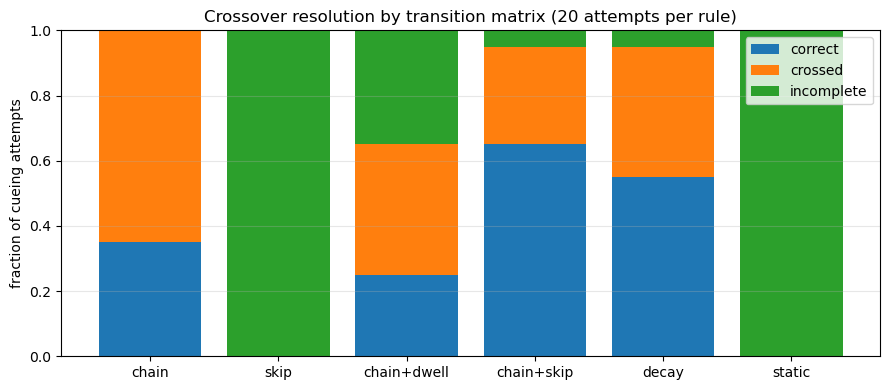

In [43]:
rules = list(outcomes)
kinds = ["correct", "crossed", "incomplete"]

fig, ax = plt.subplots(figsize=(9, 4))
bottom = np.zeros(len(rules))
for kind in kinds:
    heights = np.array([outcomes[r][kind] / total for r in rules])
    ax.bar(rules, heights, bottom=bottom, label=kind)
    bottom += heights

ax.set_ylabel("fraction of cueing attempts")
ax.set_title(f"Crossover resolution by transition matrix ({total} attempts per rule)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Note on `skip`: a decoded label is not a driven pattern

`skip`'s matrix has zero rows for patterns 0 and 1 — nothing in the dynamics ever drives
the shared centre. Yet it still returns three-label traces in most attempts, and so scores
well above zero. That is geometry, not recall.

$A[0]$, $A[2]$ and the origin are all corruptions of the same vector, so the origin sits
*between* $A[0]$ and $A[2]$ in overlap space. The trajectory from one to the other passes
through a region of high origin-overlap on the way, and `decode_sequence_online` duly logs
`('A', 1)` as it goes past. The label appears without the pattern ever having been a target
of the drive.

So a three-label trace certifies that the decoder saw the middle pattern, not that the rule
routed through it. Both `skip` and `chain+skip` land near 70-75% here and are not separable
at this sample size; the difference between them is visible in the traces, not the counts.

### Note on `chain+dwell`

$\gamma$ is set to 0.1 because the dwell term has no useful operating point here. Raising
it converts *crossed* into *incomplete* rather than into *correct* — by $\gamma = 0.3$
every attempt freezes on the cue, since with $d = 3$ the self-drive on the cued pattern
outweighs the advance term and the trajectory never leaves. Symmetric self-coupling makes
patterns stickier; it does not tell the network which branch it arrived from. That is the
substantive negative result of this sweep, and it is what motivates the scan below: the
disambiguating information has to come from an *unshared predecessor*, not from inertia.

## Scanning the skip weight

`chain+skip` is $\Sigma + w\,\Sigma^{(2)}$: the ordinary chain plus a direct vote from
two patterns back. At the crossover, $A[2]$ then receives drive from both $\xi^0$
(shared, ambiguous) and $A[0]$ (unshared, decisive), and $w$ sets how loudly the
unshared one speaks. $w = 0$ is exactly the `chain` baseline, so this scan interpolates
from it.

In [44]:
WEIGHTS = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5]

skip_scan = {}
for w in WEIGHTS:
    T = ktr.shift_transition(P) + w * ktr.shift_transition(P, nhop=2)
    net = ktr.TransitionNetwork(transition=T, N=N, seed=10, **CONFIG)
    rng = np.random.default_rng(0)      # same instances again, for every w

    counter = Counter()
    for _ in range(M):
        multi, out = run_trial(net, rng)
        for name in ("A", "B"):
            counter[out[name]["outcome"]] += 1

    skip_scan[w] = counter
    print(f"w={w:<5} correct={counter['correct'] / total:.0%}  "
          f"crossed={counter['crossed'] / total:.0%}  incomplete={counter['incomplete'] / total:.0%}")

w=0.0   correct=35%  crossed=65%  incomplete=0%
w=0.25  correct=40%  crossed=55%  incomplete=5%
w=0.5   correct=65%  crossed=30%  incomplete=5%
w=0.75  correct=65%  crossed=25%  incomplete=10%
w=1.0   correct=70%  crossed=20%  incomplete=10%
w=1.5   correct=65%  crossed=10%  incomplete=25%


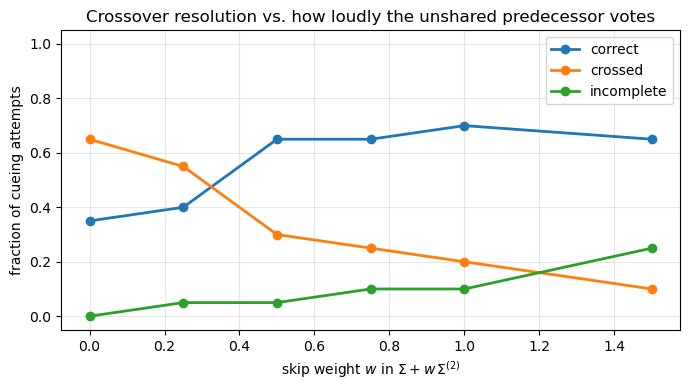

In [45]:
fig, ax = plt.subplots(figsize=(7, 4))
for kind in kinds:
    ax.plot(WEIGHTS, [skip_scan[w][kind] / total for w in WEIGHTS],
            marker="o", linewidth=2, label=kind)

ax.set_xlabel(r"skip weight $w$ in $\Sigma + w\,\Sigma^{(2)}$")
ax.set_ylabel("fraction of cueing attempts")
ax.set_title("Crossover resolution vs. how loudly the unshared predecessor votes")
ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Trial 0 under every rule

The same crossover instance, driven six ways. Read the middle of each trace: under
`chain` the two terminal patterns rise together out of the shared centre, which is the
ambiguity itself made visible.

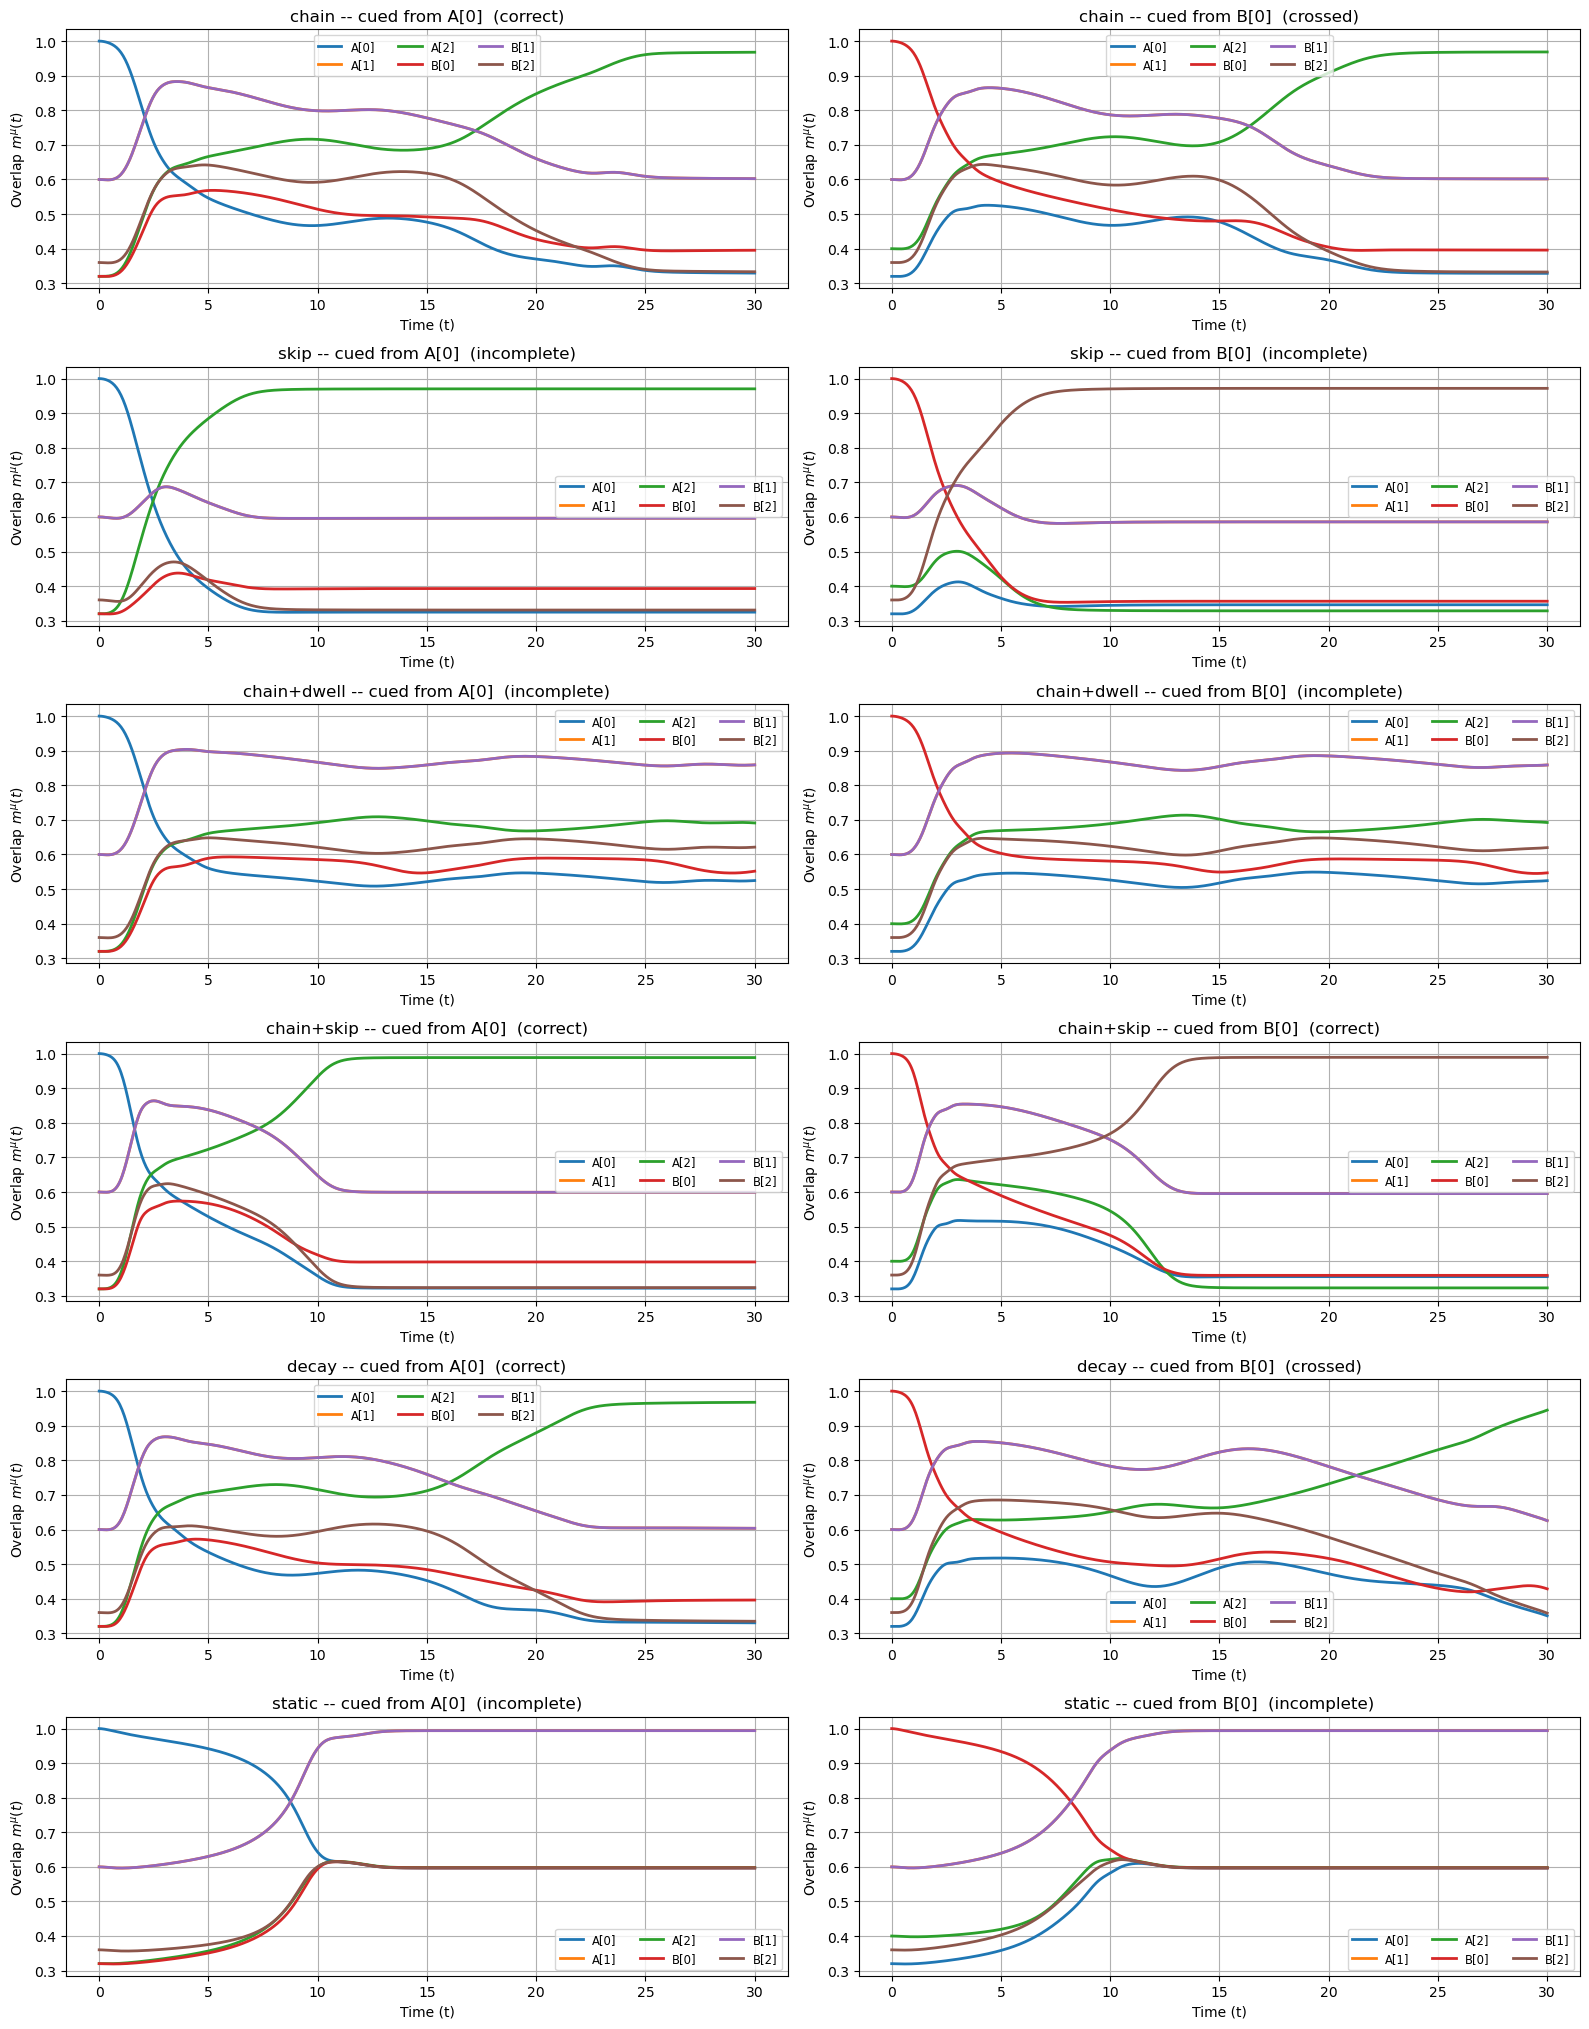

In [46]:
fig, axes = plt.subplots(len(CATALOGUE), 2, figsize=(16, 3.4 * len(CATALOGUE)))

for row, (rule, (multi, out)) in enumerate(first_trial.items()):
    net = ktr.TransitionNetwork(transition=CATALOGUE[rule], N=N, seed=10, **CONFIG)
    for col, name in enumerate(("A", "B")):
        net.plot(out[name]["result"], multi, ax=axes[row, col],
                 title=f"{rule} -- cued from {name}[0]  ({out[name]['outcome']})")

plt.tight_layout()
plt.show()

## Appendix: `skip` on its own

The `skip` row is the one whose number most needs looking at rather than reading, since
its matrix never drives the shared centre yet its traces keep producing a middle label.
These panels are just that rule.

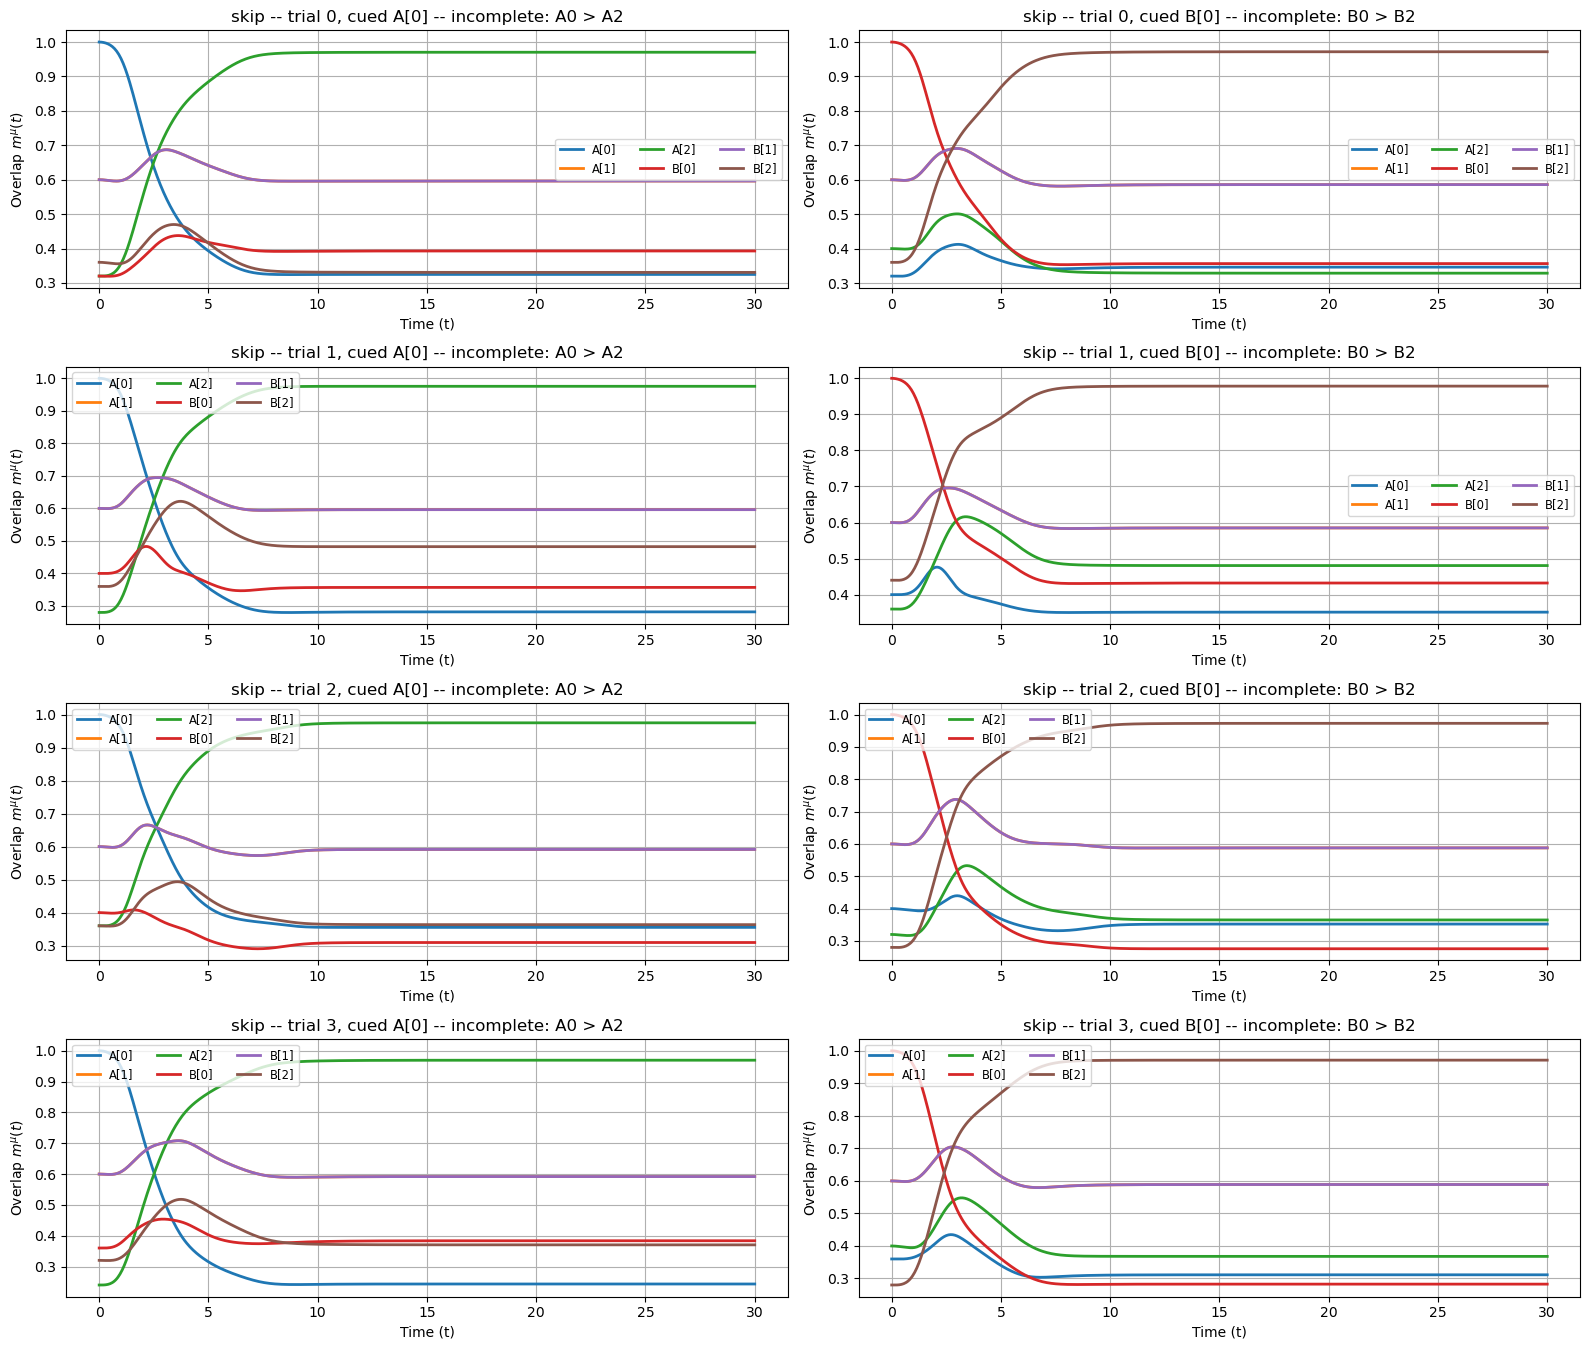

In [47]:
def path_str(retrieved):
    return " > ".join(f"{name}{idx}" for name, idx in retrieved)


SKIP_TRIALS = 4

skip_net = ktr.TransitionNetwork(transition=CATALOGUE["skip"], N=N, seed=10, **CONFIG)
skip_rng = np.random.default_rng(0)     # same instances as every sweep above

fig, axes = plt.subplots(SKIP_TRIALS, 2, figsize=(16, 3.4 * SKIP_TRIALS))
for trial in range(SKIP_TRIALS):
    multi, out = run_trial(skip_net, skip_rng)
    for col, name in enumerate(("A", "B")):
        entry = out[name]
        skip_net.plot(entry["result"], multi, ax=axes[trial, col],
                      title=f"skip -- trial {trial}, cued {name}[0] -- "
                            f"{entry['outcome']}: {path_str(entry['retrieved'])}")

plt.tight_layout()
plt.show()

### Does the centre actually get reached?

The same crossover instance under `chain` and under `skip`, cued from $A[0]$, with the peak
overlap each one attains with the shared centre. `chain` drives that pattern explicitly;
`skip` does not drive it at all (row 1 of its matrix is zero), so whatever overlap it
reaches is the trajectory passing through on its way from $A[0]$ to $A[2]$.

chain  peak overlap -- centre 0.85   A[2] 0.97   B[2] 0.67
skip   peak overlap -- centre 0.64   A[2] 0.98   B[2] 0.48


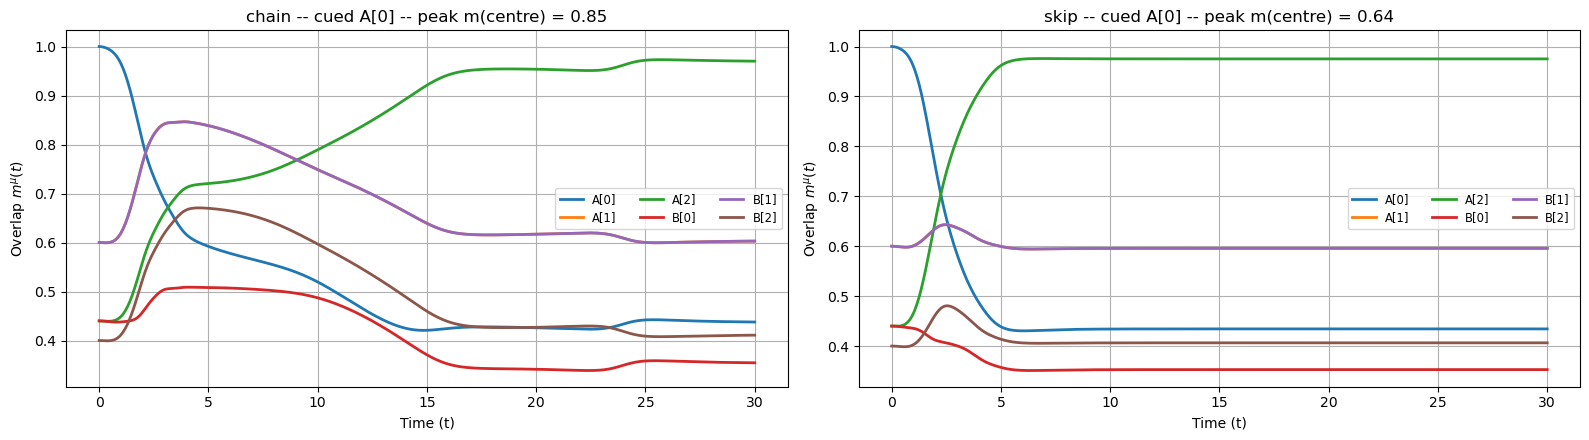

In [48]:
demo = make_crossover_multisequence(N, CONFIG["corruption_rate"], 1, [2, 3, 4, 5])
# demo.labels() == [(A,0), (A,1), (A,2), (B,0), (B,1), (B,2)]; column 1 is the shared centre.
CENTRE, OWN_END, RIVAL_END = 1, 2, 5

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
for ax, rule in zip(axes, ("chain", "skip")):
    net = ktr.TransitionNetwork(transition=CATALOGUE[rule], N=N, seed=10, **CONFIG)
    res = net.simulate(demo, cue=demo["A"], cue_idx=0)
    ov = net.overlaps(res["theta_history"], demo)

    peak_centre, peak_own, peak_rival = ov[:, CENTRE].max(), ov[:, OWN_END].max(), ov[:, RIVAL_END].max()
    print(f"{rule:6s} peak overlap -- centre {peak_centre:.2f}   A[2] {peak_own:.2f}   B[2] {peak_rival:.2f}")

    net.plot(res, demo, ax=ax,
             title=f"{rule} -- cued A[0] -- peak m(centre) = {peak_centre:.2f}")

plt.tight_layout()
plt.show()

## Where to change things

- **Which $T$'s are compared** — the `CATALOGUE` dict. Add an entry and every cell below
  picks it up.
- **Settle vs. loop at the last pattern** — `boundary="self"` (default) or `"cycle"` on
  `shift_transition` / `mixed_transition`. With `"cycle"` the "last label reached" score
  stops meaning anything, so switch to `decode_sequence_peaks` if you go that way.
- **Skip length** — `nhop` on `shift_transition`.
- **Dwell/advance balance** — `gamma` and `kappa` on `mixed_transition`.
- **Skip weight in `chain+skip`** — the `0.5` coefficient, and `WEIGHTS` for the scan;
  this is the main dial for the hypothesis under test.
- **Decay rate** — `w` in `decay_rule`.
- **Sharpening exponent** — `d` in `CONFIG` (on the network, not in $T$).
- **Disorder / noise** — `frequency_std`, and `phase_noise` with `mode="sde"`.
- **Statistics** — `M`. Each trial is two integrations; the whole sweep is
  `6 * 2 * M` runs.